# Blood Lab Analysis

For the purposes of this project, the blood labs that could contribute to metabolism and metabolic syndrome will be analyzed. The blood labs of focus are as follows:

 * Cholesterol panel
 * CBC with differential
 * Glycohemoglobin (hemoglobin A1c)
 * Insulin
 * Fasting glucose
 * Sex hormones

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
os.getcwd()

'C:\\Users\\chungs4\\Documents\\GitHub\\portfolio_ds_projects\\NHANES_analysis'

## Lipid Panel

Results are given in milligrams per deciliter (mg/dL). Here are the ranges for total cholesterol in adults:

* Normal: Less than 200 mg/dL
* Borderline high: 200 to 239 mg/dL
* High: At or above 240 mg/dL
* These are the adult ranges for LDL cholesterol:

LDL Range:

* Optimal: Less than 100 mg/dL (This is the goal for people with diabetes or heart disease.)
* Near optimal: 100 to 129 mg/dL
* Borderline high: 130 to 159 mg/dL
* High: 160 to 189 mg/dL
* Very high: 190 mg/dL and higher

High levels of triglycerides are linked with a higher heart disease risk. Here are the adult ranges:

* Normal: Less than 150 mg/dL
* Borderline high: 150 to 199 mg/dL
* High: 200 to 499 mg/dL
* Very high: Above 500 mg/dL (https://www.hopkinsmedicine.org/health/treatment-tests-and-therapies/lipid-panel)



In [3]:
df_ldl = pd.read_csv('tri_ldl_cleaned.csv')
df_hdl = pd.read_csv('hdl_cleaned.csv')
df_total = pd.read_csv('total_chol_cleaned.csv')
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_d = pd.read_csv('cleaned_demographics.csv')

In [4]:
df = df_d.merge(df_a, on='participant_id')

In [5]:
df.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty,weight_kg,weight_comment,recumbent_length_cm,standing_height,standing_height_comment,bmi,bmi_category_child,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm
0,109264.0,2.0,13.0,1.0,NaN,NaN,0.83,42.2,NaN,NaN,154.7,NaN,17.6,2.0,36.3,33.8,22.7,63.8,85.0
1,109265.0,1.0,2.0,3.0,NaN,NaN,3.06,12.0,NaN,91.6,89.3,NaN,15.0,2.0,NaN,18.6,14.8,41.2,NaN
2,109266.0,2.0,29.0,6.0,5.0,3.0,5.00,97.1,NaN,NaN,160.2,NaN,37.8,NaN,40.8,34.7,35.8,117.9,126.1
3,109269.0,1.0,2.0,2.0,NaN,NaN,0.96,13.6,NaN,90.9,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,109270.0,2.0,11.0,4.0,NaN,NaN,1.88,75.3,NaN,NaN,156.0,NaN,30.9,4.0,42.6,36.1,31.0,91.4,NaN


In [6]:
df.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'education_level',
       'marital_status', 'family_income_poverty', 'weight_kg',
       'weight_comment', 'recumbent_length_cm', 'standing_height',
       'standing_height_comment', 'bmi', 'bmi_category_child', 'upper_leg_cm',
       'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'],
      dtype='object')

In [7]:
df = df[['participant_id', 'gender', 'age_year', 'race', 'bmi']]

In [8]:
df_c = df.merge(df_ldl, on='participant_id')

In [9]:
df_c.head()

,participant_id,gender,age_year,race,bmi,Unnamed: 0,triglyceride_mg_dl,triglyceride_mmol_l,ldl_friedewald_mg_dl,ldl_friedwalkd_mmol_l,ldl_martin_hopkins_mg_dl,ldl_martin_hopkins_mmol_l,ldl_nih_mg_dl,ldl_nih_mmol_l
0,109264.0,2.0,13.0,1.0,17.6,0,40.0,0.452,86.0,2.224,82.0,2.121,85.0,2.198
1,109271.0,1.0,49.0,3.0,29.7,1,84.0,0.948,97.0,2.508,96.0,2.483,98.0,2.534
2,109274.0,1.0,68.0,7.0,30.2,2,133.0,1.502,49.0,1.267,54.0,1.396,52.0,1.345
3,109277.0,2.0,12.0,1.0,18.6,3,24.0,0.271,64.0,1.655,62.0,1.603,61.0,1.577
4,109282.0,1.0,76.0,3.0,26.6,4,132.0,1.490,164.0,4.241,163.0,4.215,166.0,4.293


In [10]:
df_c.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'bmi', 'Unnamed: 0',
       'triglyceride_mg_dl', 'triglyceride_mmol_l', 'ldl_friedewald_mg_dl',
       'ldl_friedwalkd_mmol_l', 'ldl_martin_hopkins_mg_dl',
       'ldl_martin_hopkins_mmol_l', 'ldl_nih_mg_dl', 'ldl_nih_mmol_l'],
      dtype='object')

In [11]:
df_c = df_c.drop('Unnamed: 0', axis =1)

In [12]:
df_c = df_c.merge(df_hdl, on='participant_id')

In [13]:
df_c.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'bmi',
       'triglyceride_mg_dl', 'triglyceride_mmol_l', 'ldl_friedewald_mg_dl',
       'ldl_friedwalkd_mmol_l', 'ldl_martin_hopkins_mg_dl',
       'ldl_martin_hopkins_mmol_l', 'ldl_nih_mg_dl', 'ldl_nih_mmol_l',
       'Unnamed: 0', 'direct_hdl_mg_dl', 'direct_hdl_mmol_l'],
      dtype='object')

In [14]:
df_c = df_c.drop('Unnamed: 0', axis =1)

In [15]:
df_c = df_c.merge(df_total, on='participant_id')

In [16]:
df_c.head()

,participant_id,gender,age_year,race,bmi,triglyceride_mg_dl,triglyceride_mmol_l,ldl_friedewald_mg_dl,ldl_friedwalkd_mmol_l,ldl_martin_hopkins_mg_dl,ldl_martin_hopkins_mmol_l,ldl_nih_mg_dl,ldl_nih_mmol_l,direct_hdl_mg_dl,direct_hdl_mmol_l,Unnamed: 0,total_cholesterol_mg_dl,total_cholesterol_mmol_l
0,109264.0,2.0,13.0,1.0,17.6,40.0,0.452,86.0,2.224,82.0,2.121,85.0,2.198,72.0,1.86,0,166.0,4.29
1,109271.0,1.0,49.0,3.0,29.7,84.0,0.948,97.0,2.508,96.0,2.483,98.0,2.534,33.0,0.85,3,147.0,3.80
2,109274.0,1.0,68.0,7.0,30.2,133.0,1.502,49.0,1.267,54.0,1.396,52.0,1.345,29.0,0.75,5,105.0,2.72
3,109277.0,2.0,12.0,1.0,18.6,24.0,0.271,64.0,1.655,62.0,1.603,61.0,1.577,60.0,1.55,7,129.0,3.34
4,109282.0,1.0,76.0,3.0,26.6,132.0,1.490,164.0,4.241,163.0,4.215,166.0,4.293,43.0,1.11,10,233.0,6.03


In [17]:
df_c.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'bmi',
       'triglyceride_mg_dl', 'triglyceride_mmol_l', 'ldl_friedewald_mg_dl',
       'ldl_friedwalkd_mmol_l', 'ldl_martin_hopkins_mg_dl',
       'ldl_martin_hopkins_mmol_l', 'ldl_nih_mg_dl', 'ldl_nih_mmol_l',
       'direct_hdl_mg_dl', 'direct_hdl_mmol_l', 'Unnamed: 0',
       'total_cholesterol_mg_dl', 'total_cholesterol_mmol_l'],
      dtype='object')

In [18]:
df_c = df_c.drop('Unnamed: 0', axis =1)

In [19]:
df_c.shape

(4598, 17)

In [20]:
df_c = df_c[['participant_id', 'gender', 'age_year', 'race', 'bmi','triglyceride_mg_dl','ldl_friedewald_mg_dl','ldl_martin_hopkins_mg_dl','ldl_nih_mg_dl','direct_hdl_mg_dl','total_cholesterol_mg_dl']]

In [21]:
df_c.describe(include='all')

,participant_id,gender,age_year,race,bmi,triglyceride_mg_dl,ldl_friedewald_mg_dl,ldl_martin_hopkins_mg_dl,ldl_nih_mg_dl,direct_hdl_mg_dl,total_cholesterol_mg_dl
count,4598.000000,4598.000000,4598.000000,4598.000000,4579.000000,4587.000000,4554.000000,4554.000000,4579.000000,4598.000000,4598.000000
mean,117150.267073,1.511962,45.503045,3.473032,29.187071,103.844997,105.332016,105.612429,106.866783,53.568291,179.336668
std,4474.174276,0.499911,20.461658,1.634291,7.698785,90.250111,35.205992,35.190495,35.921206,15.477225,41.061987
min,109264.000000,1.000000,12.000000,1.000000,14.600000,10.000000,7.000000,14.000000,14.000000,11.000000,73.000000
25%,113303.500000,1.000000,27.000000,3.000000,23.950000,56.000000,81.000000,81.000000,81.000000,42.000000,151.000000
50%,117212.500000,2.000000,46.000000,3.000000,27.900000,84.000000,101.000000,102.000000,103.000000,51.000000,175.000000
75%,120987.750000,2.000000,62.000000,4.000000,33.000000,126.000000,126.000000,127.000000,128.000000,61.000000,203.000000
max,124822.000000,2.000000,80.000000,7.000000,92.300000,2684.000000,357.000000,358.000000,359.000000,187.000000,446.000000


In [22]:
df_c.isna().sum()

participant_id               0
gender                       0
age_year                     0
race                         0
bmi                         19
triglyceride_mg_dl          11
ldl_friedewald_mg_dl        44
ldl_martin_hopkins_mg_dl    44
ldl_nih_mg_dl               19
direct_hdl_mg_dl             0
total_cholesterol_mg_dl      0
dtype: int64

In [23]:
df_c = df_c.dropna(subset=['bmi'])

In [24]:
df_c.isna().sum()

participant_id               0
gender                       0
age_year                     0
race                         0
bmi                          0
triglyceride_mg_dl          11
ldl_friedewald_mg_dl        44
ldl_martin_hopkins_mg_dl    44
ldl_nih_mg_dl               19
direct_hdl_mg_dl             0
total_cholesterol_mg_dl      0
dtype: int64

The appropriate calculation for the LDL cholesterol will need to be sorted out to see which column and measurements are kept. What is the most commonly used calculation typically in hospitals?

For consistency, the same way the BMI outliers were removed will be used for the blood lab analysis as well.

In [25]:
num_high_bmi = (df_c['bmi'] >= 60).sum()
print(f"Number of subjects with BMI >= 60: {num_high_bmi}")
prop_high_bmi = (df_c['bmi'] >= 60).mean()
print(f"Proportion of subjects with BMI >= 60: {prop_high_bmi:.2%}")

Number of subjects with BMI >= 60: 19
Proportion of subjects with BMI >= 60: 0.41%


In [26]:
# Count number of subjects with 50 <= BMI < 60
num_bmi_50_60 = ((df_c['bmi'] >= 50) & (df_c['bmi'] < 60)).sum()
print(f"Number of subjects with BMI between 50 and 60: {num_bmi_50_60}")
prop_bmi_50_60 = ((df_c['bmi'] >= 50) & (df_c['bmi'] < 60)).mean()
print(f"Proportion of subjects with BMI between 50 and 60: {prop_bmi_50_60:.2%}")

Number of subjects with BMI between 50 and 60: 52
Proportion of subjects with BMI between 50 and 60: 1.14%


In [27]:
chol_filtered = df_c[df_c['bmi'] <= 50].copy()

In [28]:
df_adults = chol_filtered[chol_filtered['age_year'] >= 18]

In [29]:
chol_filtered.describe()

,participant_id,gender,age_year,race,bmi,triglyceride_mg_dl,ldl_friedewald_mg_dl,ldl_martin_hopkins_mg_dl,ldl_nih_mg_dl,direct_hdl_mg_dl,total_cholesterol_mg_dl
count,4508.000000,4508.000000,4508.000000,4508.000000,4508.000000,4497.000000,4465.000000,4465.000000,4489.000000,4508.000000,4508.000000
mean,117144.828305,1.508429,45.470941,3.469166,28.735027,103.863687,105.478163,105.757223,107.024950,53.680346,179.608696
std,4470.143969,0.499984,20.513170,1.639641,6.776266,90.532111,35.278958,35.272572,35.995083,15.472202,41.155357
min,109264.000000,1.000000,12.000000,1.000000,14.600000,10.000000,7.000000,14.000000,14.000000,11.000000,73.000000
25%,113322.000000,1.000000,27.000000,3.000000,23.900000,56.000000,81.000000,81.000000,82.000000,42.000000,151.000000
50%,117184.000000,2.000000,46.000000,3.000000,27.800000,84.000000,102.000000,102.000000,103.000000,51.000000,175.000000
75%,120989.500000,2.000000,62.000000,4.000000,32.600000,126.000000,126.000000,127.000000,128.000000,62.000000,204.000000
max,124822.000000,2.000000,80.000000,7.000000,49.900000,2684.000000,357.000000,358.000000,359.000000,187.000000,446.000000


### BMI vs Triglyceride

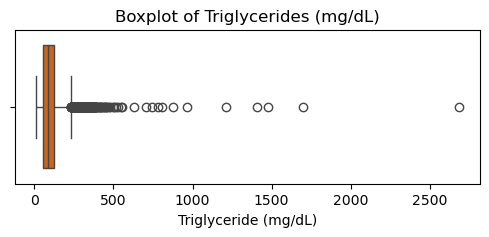

In [30]:
plt.figure(figsize=(6,2))
sns.boxplot(x=chol_filtered['triglyceride_mg_dl'], color='#E66100')
plt.title("Boxplot of Triglycerides (mg/dL)")
plt.xlabel("Triglyceride (mg/dL)")
plt.show()

75% quartile of the triglyceride level is 126 mg/dL in this dataset which is generally within normal limits. The concerning levels are when it goes above 200 mg/dL. The percentage of the values above 500 mg/dL should be assessed for removal to proceed with this analysis. Any value above 500 mg/dL is severely concerning.

In [31]:
# Define your threshold
threshold = 500  

# Count how many subjects exceed the threshold
extreme_count = (chol_filtered['triglyceride_mg_dl'] >= threshold).sum()

# Total number of subjects
total_count = chol_filtered['triglyceride_mg_dl'].notna().sum()

# Percentage
extreme_percent = (extreme_count / total_count) * 100

print(f"Subjects with extreme triglyceride values (≥ {threshold} µg/mL): {extreme_count}")
print(f"Total subjects with triglyceride values: {total_count}")
print(f"Percentage extreme: {extreme_percent:.2f}%")

Subjects with extreme triglyceride values (≥ 500 µg/mL): 17
Total subjects with triglyceride values: 4497
Percentage extreme: 0.38%


In [32]:
# Keep only subjects below threshold
chol_clean = chol_filtered[chol_filtered['triglyceride_mg_dl'] < threshold].copy()

print(f"Original: {chol_filtered.shape[0]} rows")
print(f"After removing extreme albumin values: {chol_clean.shape[0]} rows")

Original: 4508 rows
After removing extreme albumin values: 4480 rows


In [33]:
df_obese = chol_clean[chol_clean['bmi'] >= 30]

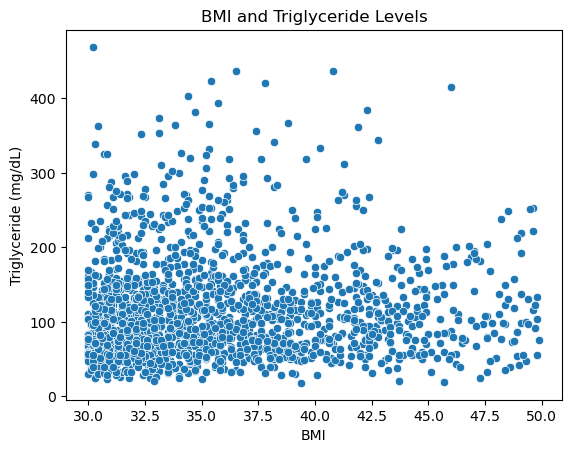

In [34]:
sns.scatterplot(x='bmi',y='triglyceride_mg_dl',data=df_obese)
plt.xlabel('BMI')
plt.ylabel('Triglyceride (mg/dL)')
plt.title('BMI and Triglyceride Levels')
plt.show()

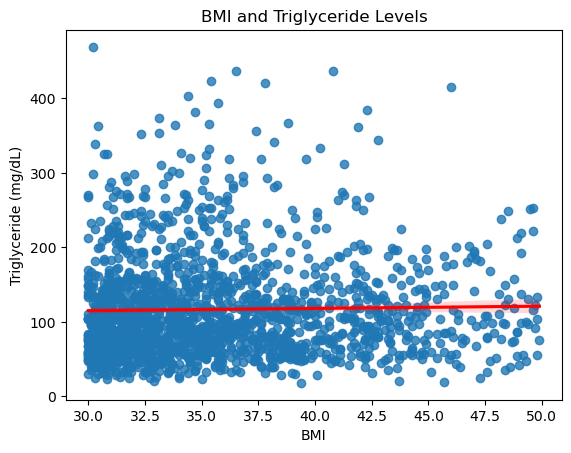

In [35]:
sns.regplot(x='bmi',y='triglyceride_mg_dl',data=df_obese,line_kws={"color": "red"})
plt.xlabel('BMI')
plt.ylabel('Triglyceride (mg/dL)')
plt.title('BMI and Triglyceride Levels')
plt.show()

When the triglyceride levels are spanned from normal to obese, there is a slight positive correlation. However, within the obese population, there does not seem to be a correlation based on the linear regression.

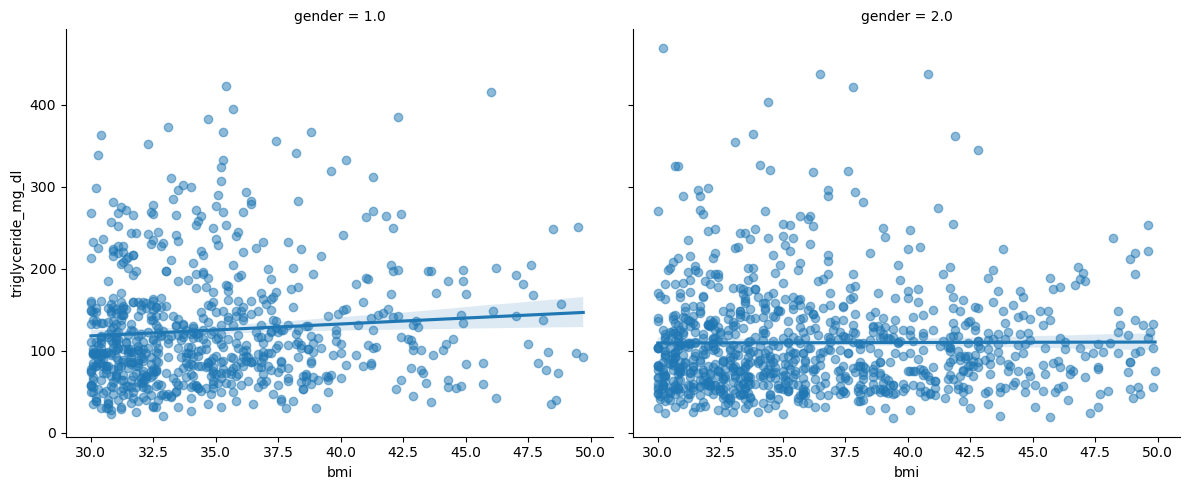

In [36]:
sns.lmplot(
    x="bmi",
    y="triglyceride_mg_dl",
    col="gender",
    data=df_obese,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

### BMI vs Total Cholesterol

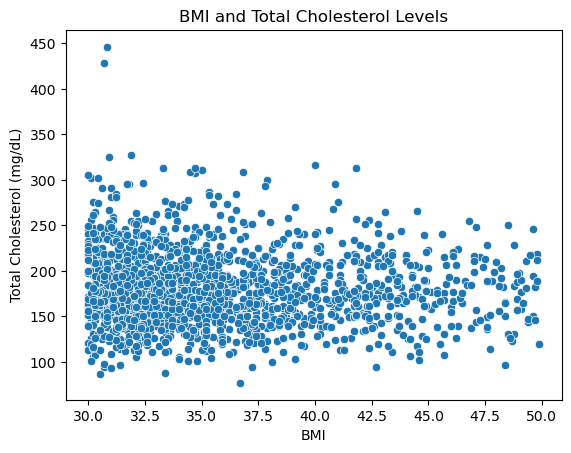

In [37]:
sns.scatterplot(x='bmi',y='total_cholesterol_mg_dl',data=df_obese)
plt.xlabel('BMI')
plt.ylabel('Total Cholesterol (mg/dL)')
plt.title('BMI and Total Cholesterol Levels')
plt.show()

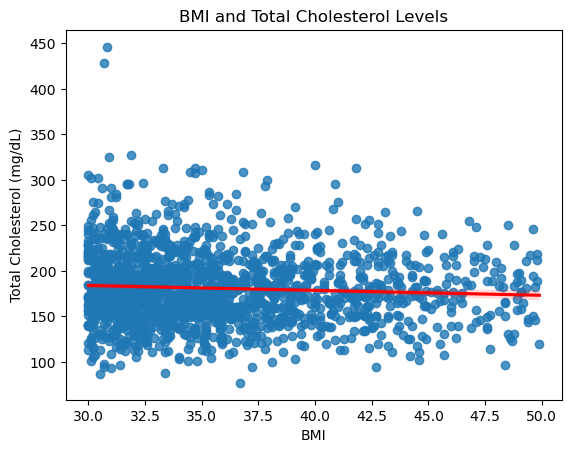

In [38]:
sns.regplot(x='bmi',y='total_cholesterol_mg_dl',data=df_obese,line_kws={"color": "red"})
plt.xlabel('BMI')
plt.ylabel('Total Cholesterol (mg/dL)')
plt.title('BMI and Total Cholesterol Levels')
plt.show()

There seems to be a slight negative correlation between BMI and total cholesterol. 

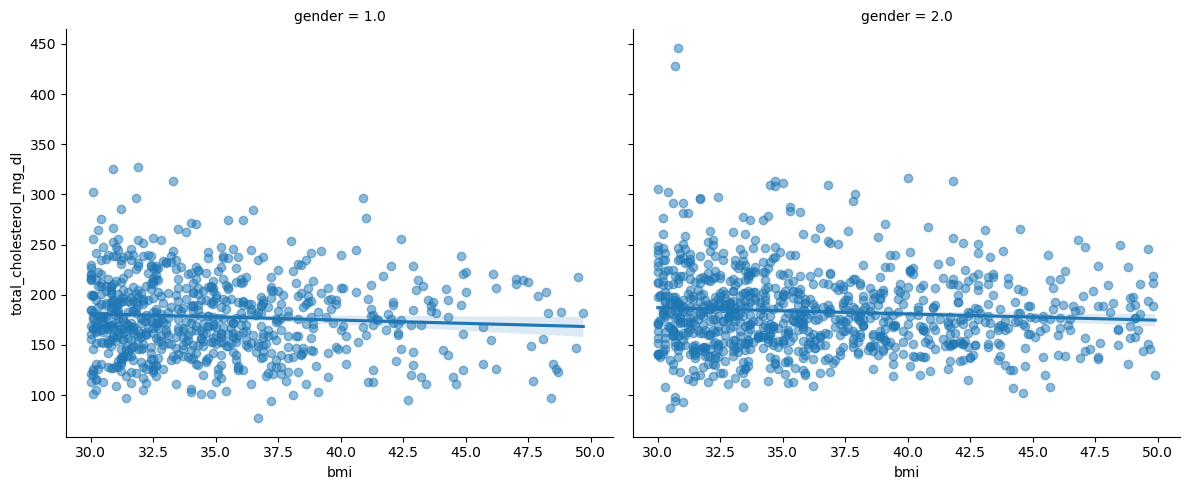

In [39]:
sns.lmplot(
    x="bmi",
    y="total_cholesterol_mg_dl",
    col="gender",
    data=df_obese,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

### BMI and LDL

Text(0.5, 1.0, 'Regression Plot')

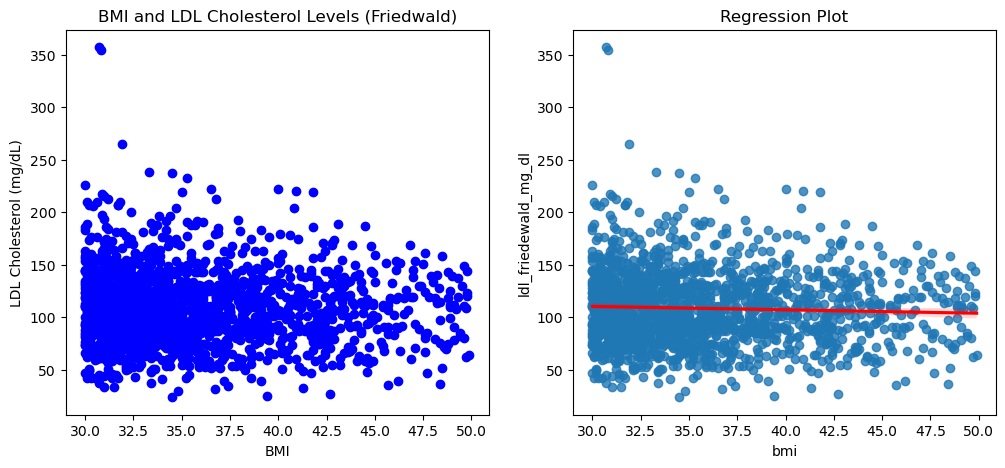

In [40]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(df_obese['bmi'], df_obese['ldl_friedewald_mg_dl'], color='blue')
axes[0].set_title('BMI and LDL Cholesterol Levels (Friedwald)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('LDL Cholesterol (mg/dL)')

# Regression plot (using seaborn)
sns.regplot(x='bmi',y='ldl_friedewald_mg_dl',data=df_obese, ax=axes[1],line_kws={"color": "red"})
axes[1].set_title('Regression Plot')

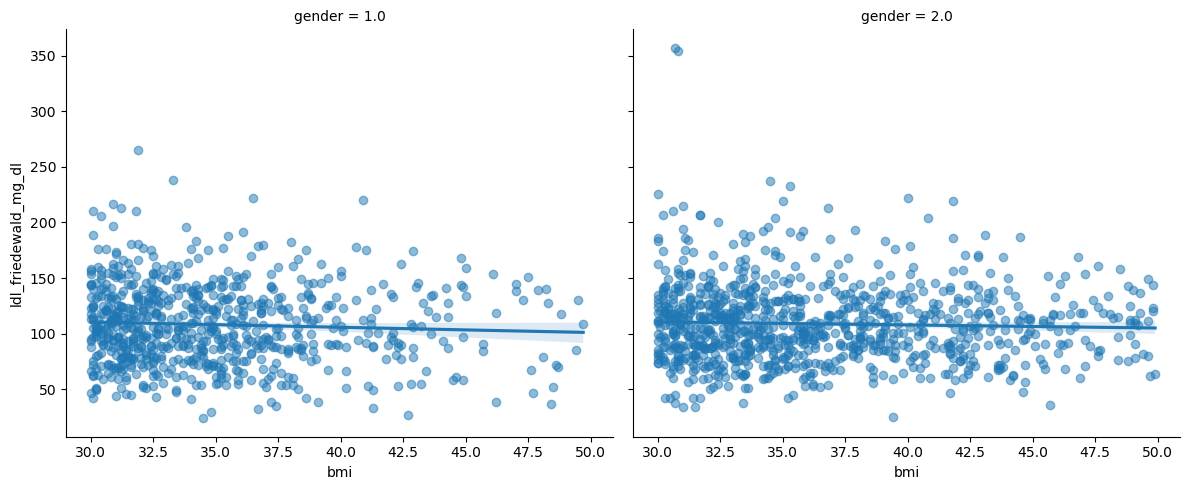

In [41]:
sns.lmplot(
    x="bmi",
    y="ldl_friedewald_mg_dl",
    col="gender",
    data=df_obese,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

Text(0.5, 1.0, 'Regression Plot')

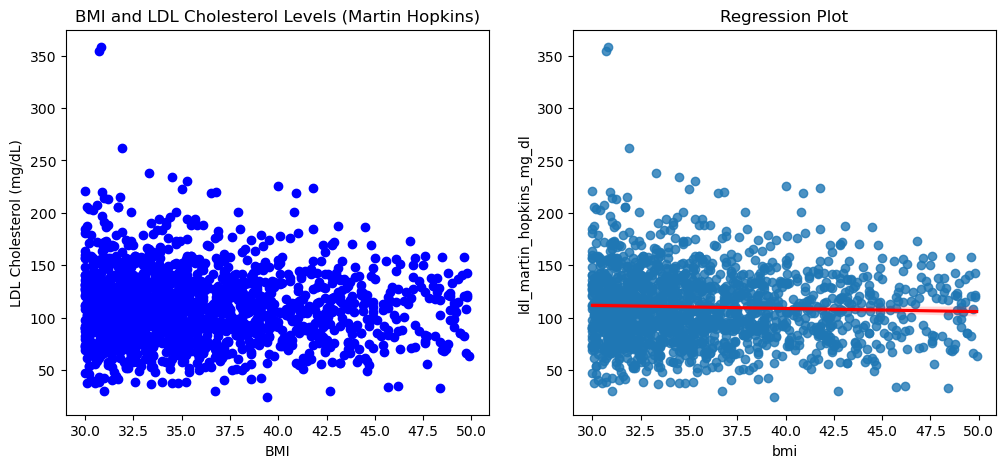

In [42]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(df_obese['bmi'], df_obese['ldl_martin_hopkins_mg_dl'], color='blue')
axes[0].set_title('BMI and LDL Cholesterol Levels (Martin Hopkins)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('LDL Cholesterol (mg/dL)')

# Regression plot (using seaborn)
sns.regplot(x='bmi',y='ldl_martin_hopkins_mg_dl',data=df_obese, ax=axes[1],line_kws={"color": "red"})
axes[1].set_title('Regression Plot')

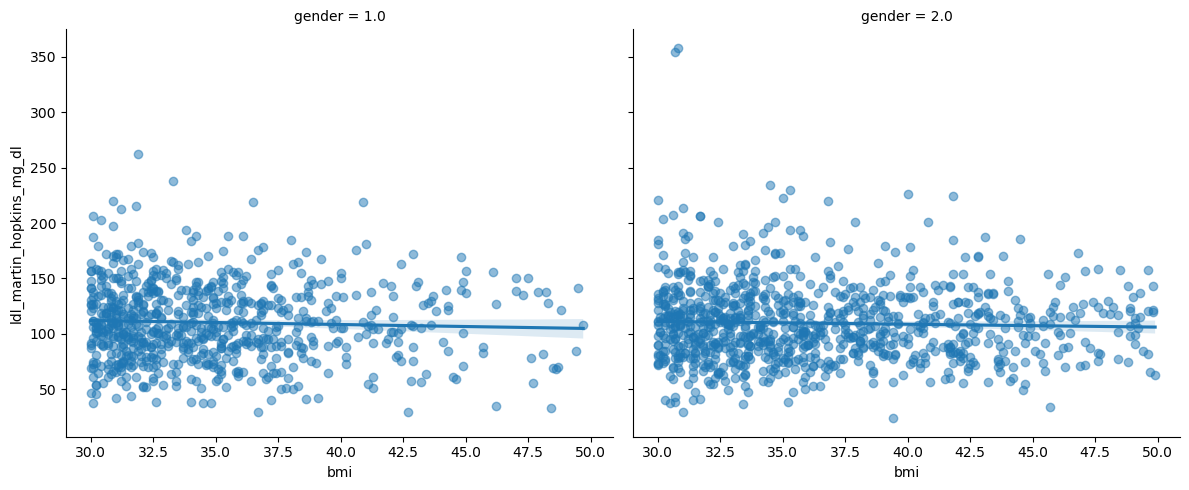

In [43]:
sns.lmplot(
    x="bmi",
    y="ldl_martin_hopkins_mg_dl",
    col="gender",
    data=df_obese,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

Text(0.5, 1.0, 'Regression Plot')

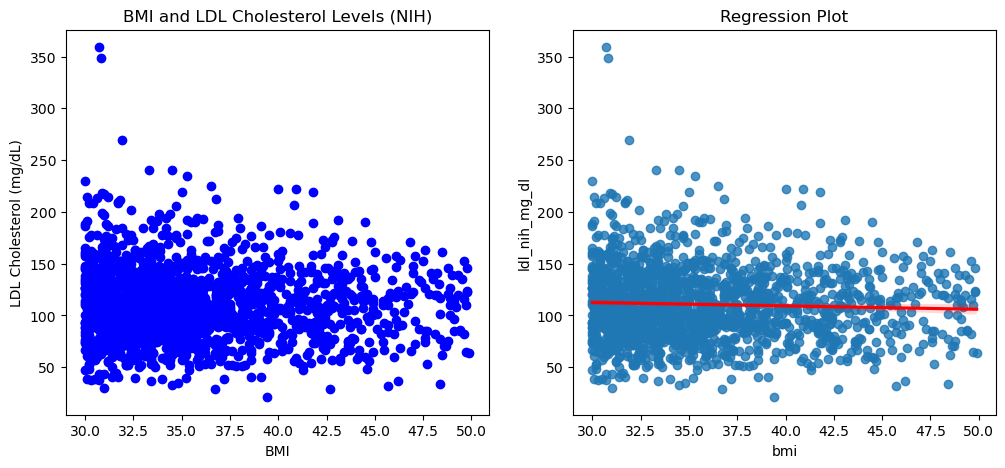

In [44]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(df_obese['bmi'], df_obese['ldl_nih_mg_dl'], color='blue')
axes[0].set_title('BMI and LDL Cholesterol Levels (NIH)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('LDL Cholesterol (mg/dL)')

# Regression plot (using seaborn)
sns.regplot(x='bmi',y='ldl_nih_mg_dl',data=df_obese, ax=axes[1],line_kws={"color": "red"})
axes[1].set_title('Regression Plot')

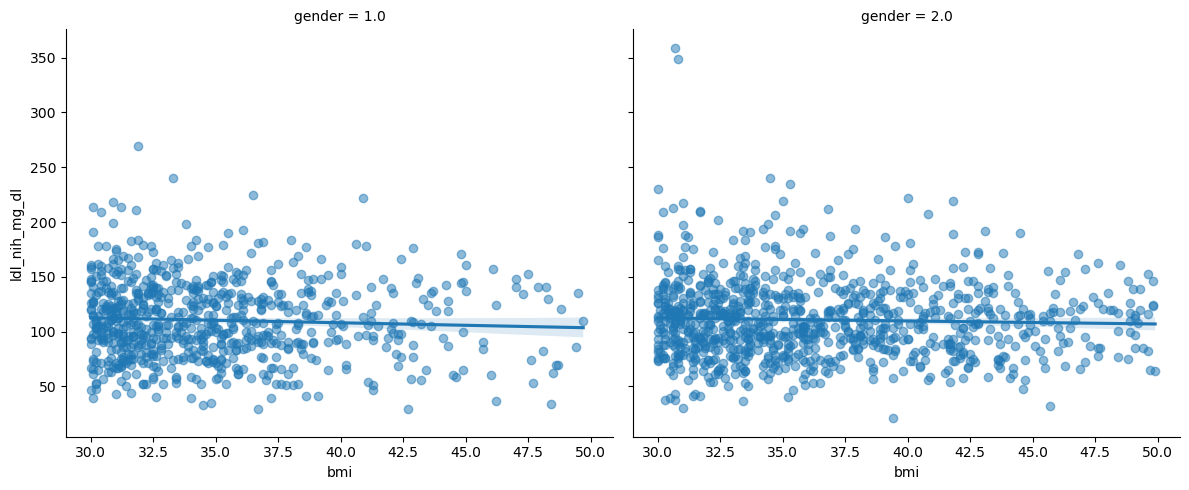

In [45]:
sns.lmplot(
    x="bmi",
    y="ldl_nih_mg_dl",
    col="gender",
    data=df_obese,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

### BMI and HDL

Text(0.5, 1.0, 'Regression Plot')

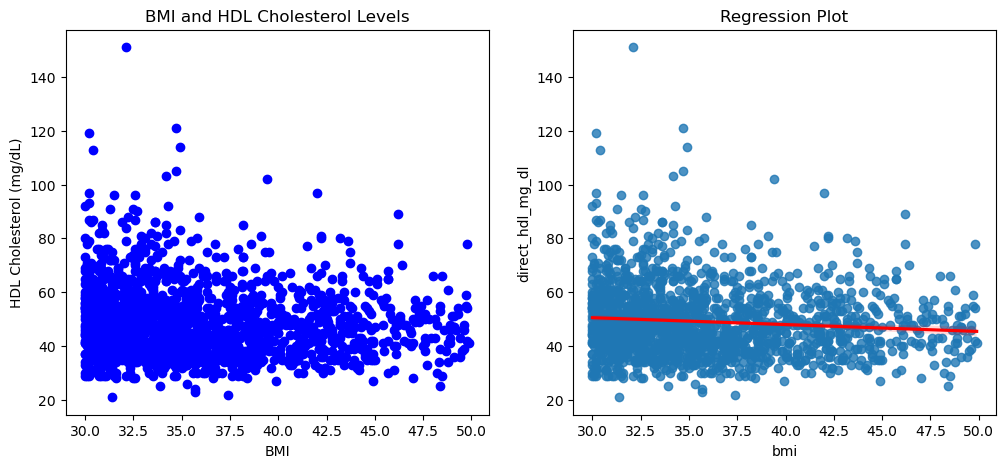

In [46]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(df_obese['bmi'], df_obese['direct_hdl_mg_dl'], color='blue')
axes[0].set_title('BMI and HDL Cholesterol Levels')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('HDL Cholesterol (mg/dL)')

# Regression plot (using seaborn)
sns.regplot(x='bmi',y='direct_hdl_mg_dl',data=df_obese, ax=axes[1],line_kws={"color": "red"})
axes[1].set_title('Regression Plot')

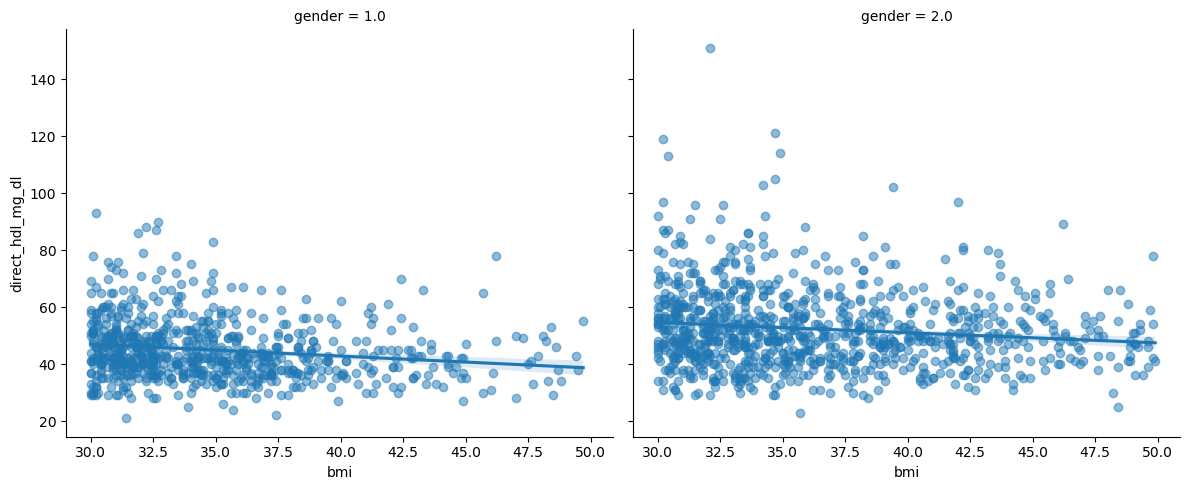

In [47]:
sns.lmplot(
    x="bmi",
    y="direct_hdl_mg_dl",
    col="gender",
    data=df_obese,
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}  # optional: make points semi-transparent
)
plt.show()

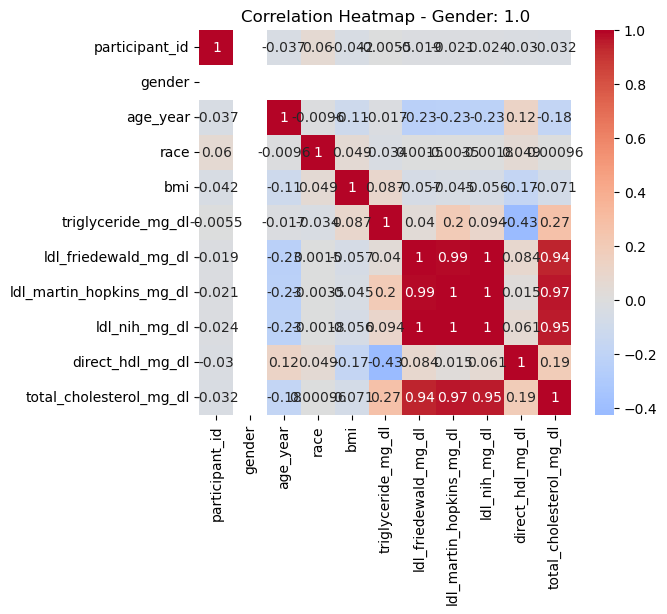

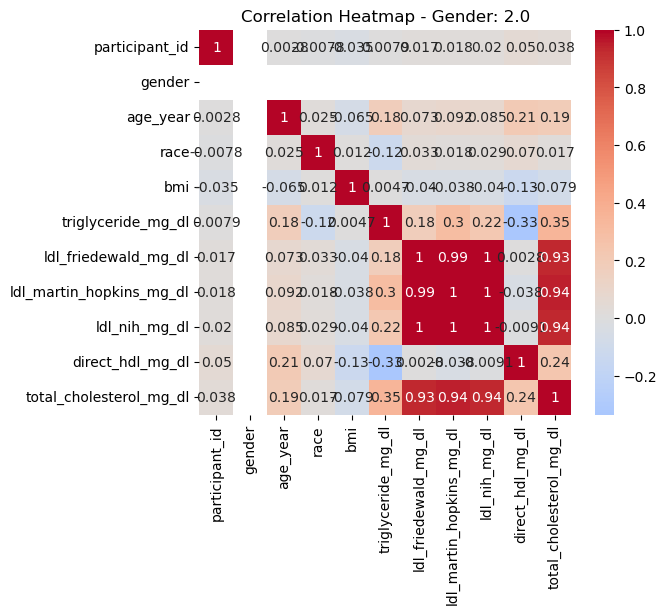

In [48]:
for gender, df_group in df_obese.groupby('gender'):
    corr_matrix = df_group.corr()
    
    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Heatmap - Gender: {gender}')
    plt.show()